# 🐢 EPOCH Pilot Task Week 1
> 주제: 카드 소비 데이터에 기반한 고객 유형별 이탈 요인 분석

### TASK 1. 데이터 출처 설명 / 불러오기

* 데이터: Kaggle - Credit Card customers
(https://www.kaggle.com/datasets/sakshigoyal7/credit-card-customers)

* 개요: This dataset consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc. There are nearly 18 features. We have only 16.07% of customers who have churned.

선정 이유: 카드 결제 데이터는 한 사람의 일상에 가장 가까운 데이터라고 생각합니다. 이전부터 그 점이 상당히 매력적으로 느껴졌고, 언젠가 꼭 한번은 분석해보고 싶은 데이터였습니다.

카드 이탈 분석은 사실 상당히 보편적인 주제이긴 하나, 그만큼 카드사 입장에서 가장 중요한 과제 중 하나이기도 합니다. (많이들 하는 이유가 있는..) 그리고 보편적이기에 수많은 선행 분석 사례를 참고할 수 있다는 점에서 해당 주제를 선택했습니다 ^_^

> features (영문)
* CLIENTNUM: Client number. Unique identifier for the customer holding the account

* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then 1 else 0

* Customer_Age: Demographic variable - Customer's Age in Years

* Gender: Demographic variable - M=Male, F=Female

* Dependent_count: Demographic variable - Number of dependents

* Education_Level: Demographic variable - Educational Qualification of the account holder (example: high school, college graduate, etc.)

* Matiral_Status: Demographic variable - Married, Single, Divorced, Unknown

* Income_Category: Demographic variable - Annual Income Category of the account holder (< $40K, $40K - 60K, $60K - $80K, $80K-$120K, > $120K, Unknown)

* Card_Category: Product Variable - Type of Card (Blue, Silver, Gold, Platinum)

* Months_on_book: Period of relationship with bank

* Total_Relationship_Count: Total no. of products held by the customer

* Months_Inactive_12_mon: No. of months inactive in the last 12 months

* Contacts_Count_12_mon: No. of Contacts in the last 12 months

* Credit_Limit: Credit Limit on the Credit Card

* Total_Revolving_Bal: Total Revolving Balance on the Credit Card

* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)

* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)

* Total_Trans_Amt: Total Transaction Amount (Last 12 months)

* Total_Trans_Ct: Total Transaction Count (Last 12 months)

* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)

* Avg_Utilization_Ratio: Average Card Utilization Ratio

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2


> features (한글)

✏️ **고객 식별 및 타겟 변수**
* CLIENTNUM: 고객 번호 (고유 식별자)

* Attrition_Flag: 이탈 여부 (해지하면 1, 유지 중이면 0)

***

✏️ **인구통계학적 변수**
* Customer_Age: 나이 (만 나이)

* Gender: 성별

* Dependent_count: 부양가족 수

* Education_Level: 학력 수준 (예: 고졸, 대졸, 대학원 등)

* Matiral_Status: 결혼 상태 (기혼, 미혼, 이혼, 미상)

* Income_Category: 연 소득 (소득 구간)

***

✏️ **카드/상품 관련 변수**

* Card_Category: 카드 등급 (Blue, Silver, Gold, Platinum)

* Months_on_book: 거래 유지 기간 (개월 단위)

* Total_Relationship_Count: 보유한 은행 상품의 총 개수

* Months_Inactive_12_mon: 최근 12개월 중 카드 사용이 없던 개월 수

* Contacts_Count_12_mon: 최근 12개월 고객센터 접촉 횟수

* Credit_Limit: 신용카드 한도 금액

* Total_Revolving_Bal: 총 리볼빙 잔액 (결제하지 않고 이월된 금액)

* Avg_Open_To_Buy: 최근 12개월 평균 사용 가능한 잔여 한도 (신용한도-사용금액)

* Total_Amt_Chng_Q4_Q1: 4분기 대비 1분기 거래 금액 변화율

* Total_Trans_Amt: 최근 12개월 총 거래 금액

* Total_Trans_Ct: 최근 12개월 총 거래 횟수

* Total_Ct_Chng_Q4_Q1: 4분기 대비 1분기 거래 횟수 변화율

* Avg_Utilization_Ratio: 평균 카드 사용률 (사용금액/신용한도)

***

✏️ **Naive Bayes 관련 변수**

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: 나이브 베이즈 모델이 예측한 이탈 확률값

* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: 나이브 베이즈 모델이 예측한 유지 확률값


#### 데이터 불러오기

In [1]:
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/BankChurners.csv')
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [4]:
df.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.0,1961,8427.0,0.703,10294,61,0.649,0.189,0.996620,0.003377


* 우선, 마지막 2개 특성의 이름이 너무 길어서 읽기 번거로운 데다가, 분석이 끝난 후 검증 단계에서만 활용할 컬럼이므로 삭제

In [5]:
df = df.iloc[:, :-2]

In [6]:
df.shape

(10127, 21)

* 총 10,127명의 고객에 대한 21개 특성을 나타낸 데이터 준비 완료

### TASK 2. 기초 통계 확인

#### 변수 확인

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

##### 수치형 변수

In [8]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


##### 범주형 변수

In [9]:
df.describe(include='object').T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [10]:
# unique한 값의 개수와 비율을  출력하는 함수 정의
def category_unique_value():
    for cat_cols in (
        df.select_dtypes(exclude=[np.int64, np.float64]).columns.unique().to_list()
    ):
        print(cat_cols)
        df_temp = pd.concat(
            [
                df[cat_cols].value_counts(),
                df[cat_cols].value_counts(normalize=True) * 100,
            ],
            axis=1,
        )
        df_temp.columns = ["Count", "Percentage"]
        print(df_temp)
        print("-" * 20)

In [11]:
category_unique_value()

Attrition_Flag
                   Count  Percentage
Attrition_Flag                      
Existing Customer   8500   83.934038
Attrited Customer   1627   16.065962
--------------------
Gender
        Count  Percentage
Gender                   
F        5358   52.908068
M        4769   47.091932
--------------------
Education_Level
                 Count  Percentage
Education_Level                   
Graduate          3128   30.887726
High School       2013   19.877555
Unknown           1519   14.999506
Uneducated        1487   14.683519
College           1013   10.002962
Post-Graduate      516    5.095290
Doctorate          451    4.453441
--------------------
Marital_Status
                Count  Percentage
Marital_Status                   
Married          4687   46.282216
Single           3943   38.935519
Unknown           749    7.396070
Divorced          748    7.386195
--------------------
Income_Category
                 Count  Percentage
Income_Category                   
Less t

* unknown 값: Education_Level, Marital_Status, Income_Category에 존재
* ~93%의 사용자가 Blue Card를 사용한다.
* 기혼 & 미혼 비율이 이혼 & 미상에 비해 5배 높은 비율
* 교육 수준 비율 균등하지 않다: 대학원, 박사 학위 비율 낮음 (둘이 합쳐서 9%)

#### 결측치, 중복값 확인

In [12]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [13]:
df.duplicated().sum()

np.int64(0)

* 중복 데이터 없음
* NULL 값은 없음 (하지만 **unknown** 값이 있는 칼럼 존재)

### TASK 3. 분석 목적/인사이트 설명

> **⭐️ 최종 목표**

: 사용자 유형별 주요 이탈 요인을 기반으로 차별화된 리텐션 전략을 제시한다. 
신규 고객 발생 시 해당 고객을 적절한 군집으로 분류하여 자동으로 맞춤형 전략을 제공할 수 있도록 한다.

1. 연령, 성별 등 인구통계학적 특성에 따른 카드 소비 패턴을 분석하고, 이를 기반으로 고객을 군집화한다.
2. 도출된 군집별로 카드/상품 관련 변수 중 이탈에 유의미하게 기여하는 요인을 도출한다.

 (추가로, 본 데이터에서 제시된 베이즈 모델의 이탈/유지 예측 확률과 분석 결과를 비교함으로써 분석 결과를 검증한다.)


### TASK 4. EDA

> 이탈률 확인

In [14]:
counts = df['Attrition_Flag'].value_counts()
counts

,count
Attrition_Flag,
Existing Customer,8500
Attrited Customer,1627


In [15]:
churn_rate = (df['Attrition_Flag'] == 'Attrited Customer').mean()
print(churn_rate)

0.1606596227905599


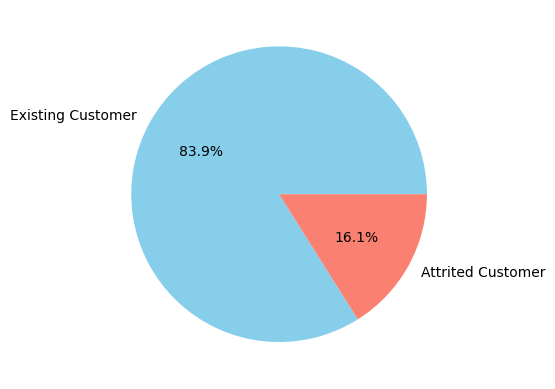

In [16]:
df['Attrition_Flag'].value_counts().plot.pie(autopct='%1.1f%%',
                                             colors=['skyblue', 'salmon'])
plt.ylabel('')
plt.show()

* 이탈률은 약 16%인 것으로 확인

#### Uni/Bivariate Analysis

> 범주형 변수 확인

In [ ]:
# 1. Attrition_Flag를 기반으로 'churn' 컬럼 생성 (이탈=1, 유지=0)
df['churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

# 2. 범주형 변수 자동 추출 (object 또는 category 타입)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. 분석에 불필요한 타겟 변수 및 ID성 컬럼 제외
exclude_cols = ['Attrition_Flag', 'churn', 'CLIENTNUM']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

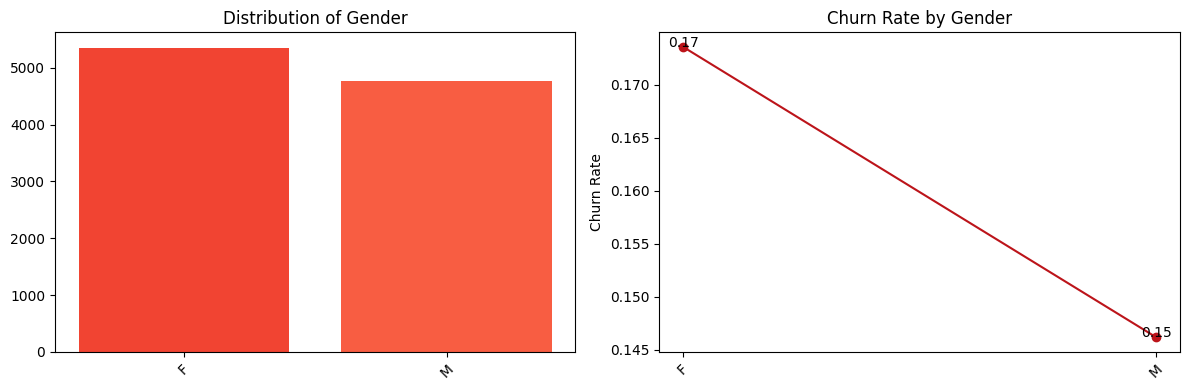

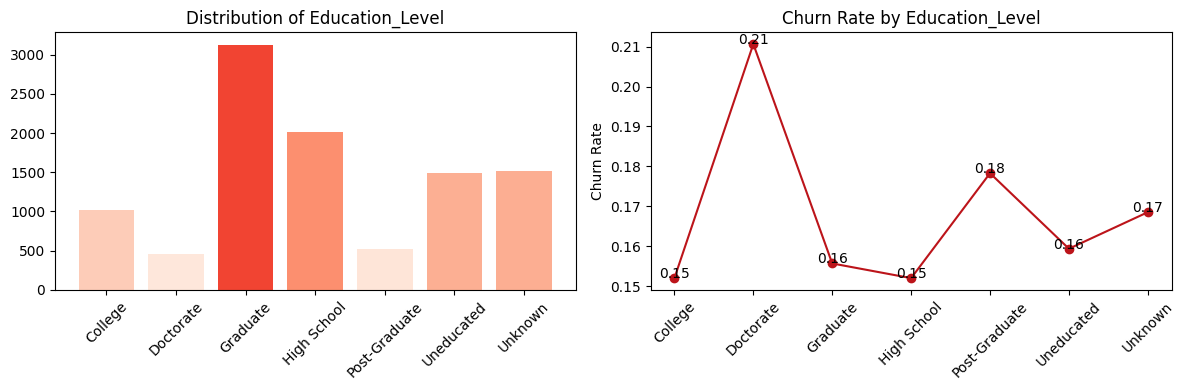

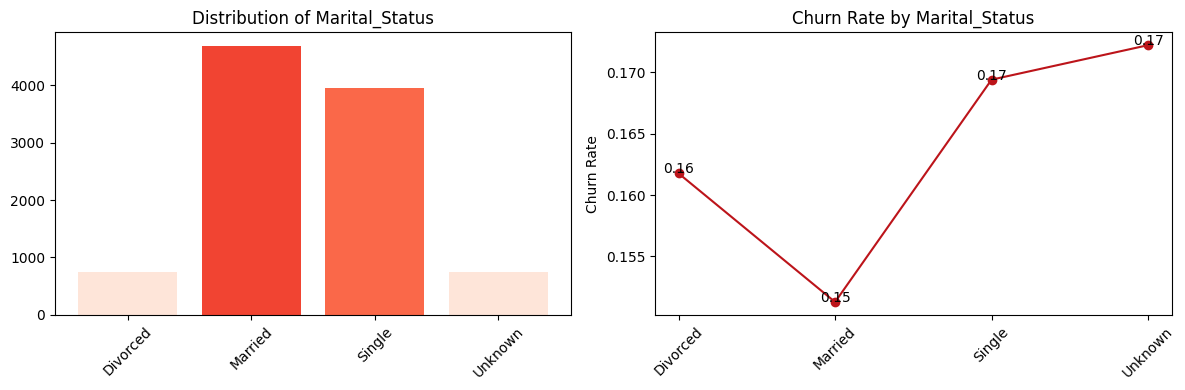

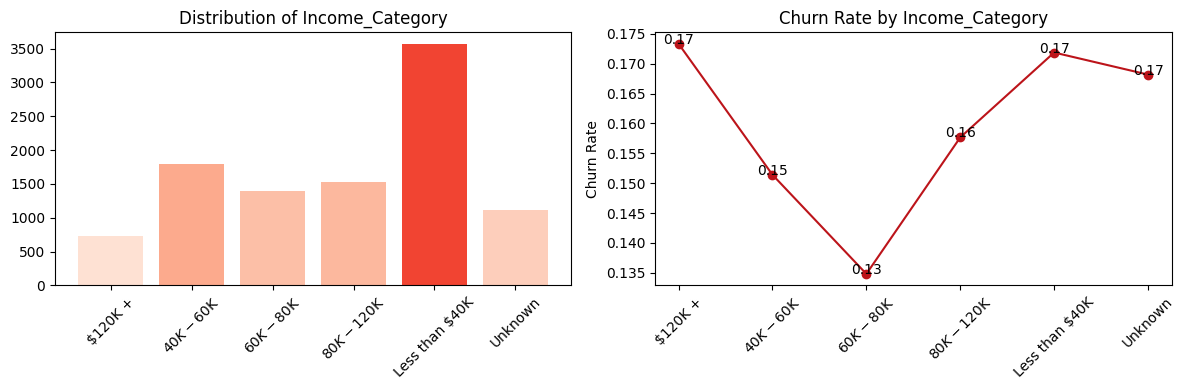

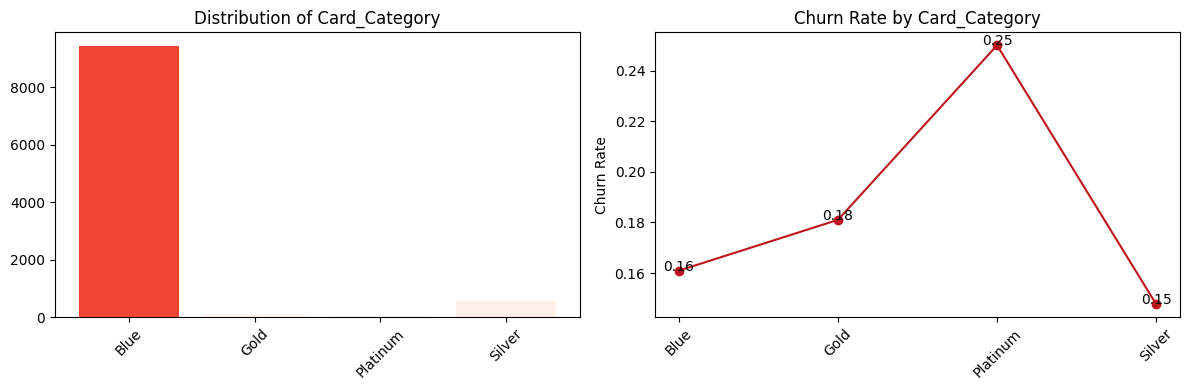

In [ ]:
categorical_cols = [col for col in categorical_cols if col != 'Attrition_Flag']
for col in categorical_cols:

    fig, axes = plt.subplots(1,2,figsize=(12,4))

    # 분포
    counts = df.groupby(col).size()

    colors = plt.cm.Reds(0.6 * counts.values / counts.values.max())

    axes[0].bar(counts.index, counts.values, color=colors)
    axes[0].set_title(f'Distribution of {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # 이탈률
    churn_rate = df.groupby(col)['churn'].mean()
    axes[1].plot(churn_rate.index, churn_rate.values, marker='o',
                 color=plt.cm.Reds(0.8))

    axes[1].set_title(f'Churn Rate by {col}')
    axes[1].set_ylabel('Churn Rate')

    for i,v in enumerate(churn_rate.values):
        axes[1].text(i,v,f'{v:.2f}',ha='center')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

* 성별 자체는 churn rate와 직접적인 관련성을 보기 어렵다. (비슷하게 나타난다.)

* Doctorate에서 높은 이탈률 보이지만, 표본 수가 너무 적어 해석에 주의가 필요하다. 중간 교육 수준인 High School, College에서 이탈률 낮게 나타난다.

* 미혼 > 기혼으로 나타난다. 표본의 수가 비슷한 이혼, unknown을 함께 봤을 때 unknown의 이탈률이 상당히 높다. unknown 집단만의 특성이 있을 것으로 기대할 수 있다.

* 중위소득에서 이탈률이 제일 낮은 패턴을 보인다.

* Blue 등급의 카드 이용자가 대부분을 차지한다. 이탈률 비교 해석은 제한적일 것으로 보인다.

변수들의 churn rate이 대부분 0.15~0.2에 그치는 것을 보아, 위의 변수들은 영향이 크지 않은 것으로 보인다.

#### 수치형 변수 확인

> 변수 구분 (이산형/연속형)

In [19]:
# ID, 타겟 제외
exclude_cols = ['CLIENTNUM', 'Attrition_Flag', 'churn']

# 수치형 전체
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# 이산형(카운트형) 후보: 고유값 개수가 적은 정수형
discrete_cols = [c for c in numeric_cols 
                 if (df[c].nunique() <= 10) and (pd.api.types.is_integer_dtype(df[c]))]

# 연속형: 나머지
continuous_cols = [c for c in numeric_cols if c not in discrete_cols]

print("Discrete:", discrete_cols)
print("Continuous:", continuous_cols)

Discrete: ['Dependent_count', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon']
Continuous: ['Customer_Age', 'Months_on_book', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


> 이산형 변수 확인

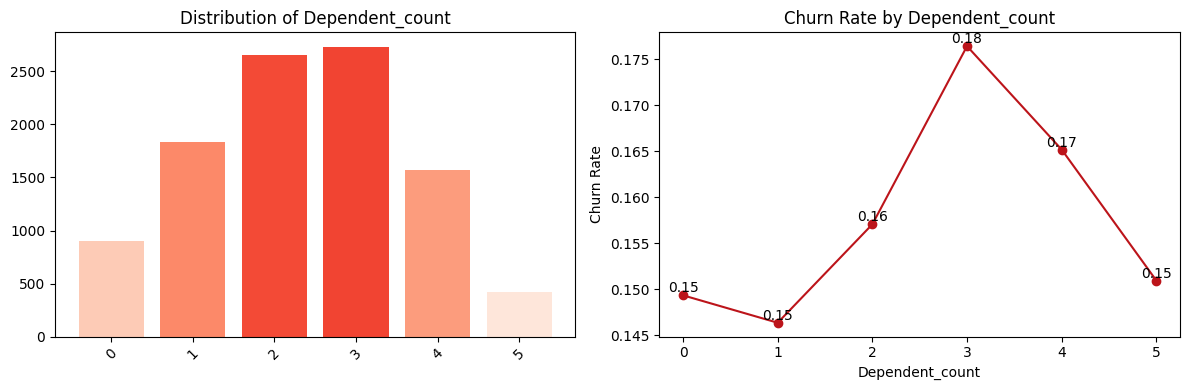

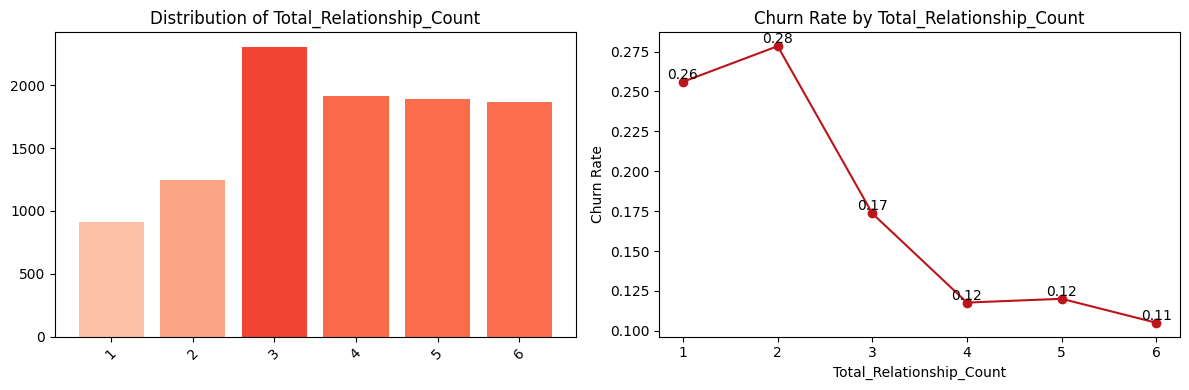

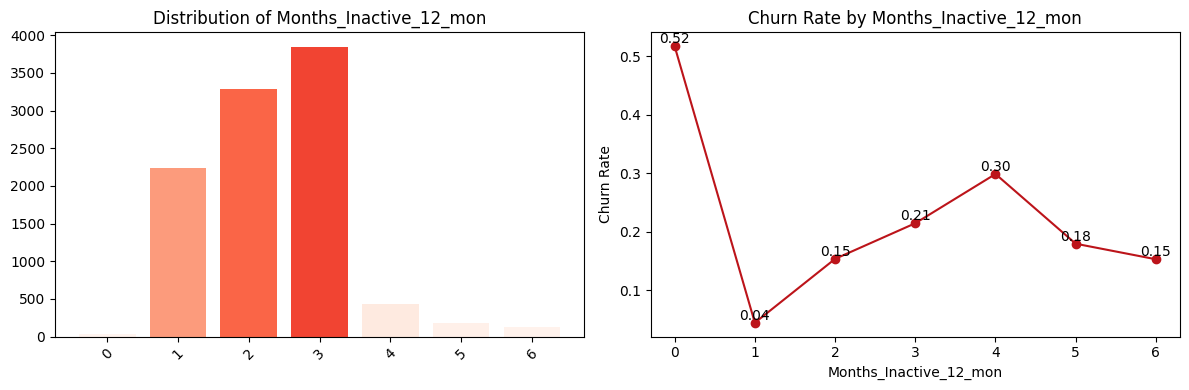

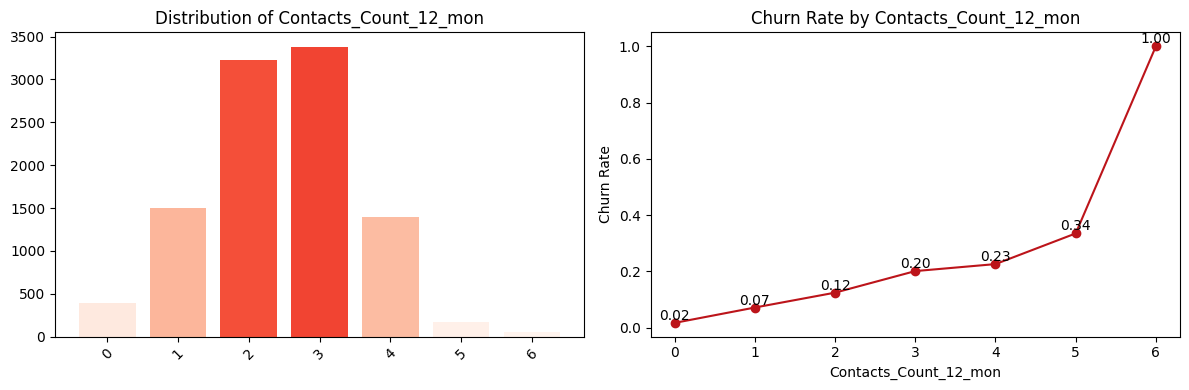

In [45]:
for col in discrete_cols:

    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # 분포
    counts = df.groupby(col).size()

    colors = plt.cm.Reds(0.6 * counts.values / counts.values.max())

    axes[0].bar(counts.index, counts.values, color=colors)
    axes[0].set_title(f'Distribution of {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # 이탈률
    churn_rate = df.groupby(col)['churn'].mean()

    axes[1].plot(churn_rate.index.astype(str), churn_rate.values, marker='o',
                 color=plt.cm.Reds(0.8))
    axes[1].set_title(f'Churn Rate by {col}')
    axes[1].set_ylabel('Churn Rate')
    axes[1].set_xlabel(col)

    # 숫자 표시
    for i, v in enumerate(churn_rate.values):
        axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

* 부양가족 수는 2~3명이 제일 많다. 다만 부양가족 수에 따른 뚜렷한 패턴은 보이지 않는다. 3~4명 구간에서 이탈률이 약간 높게 나타나지만, 전체적으로 이탈률이 0.2를 넘지 못한다.

* 3개 이상의 상품 보유한 고객들의 표본 수가 많다. 보유 상품 수가 적은 고객일 수록 이탈률이 높고, 보유 상품 수가 3개 이상으로 늘어나면 이탈률이 크게 감소한다 -> 유의미한 변수로 보인다.

* 비활성 기간이 길어질수록 전반적으로 일탈률이 높아지는 경향이 있다. 다만, 0개월과 4개월 이후 구간은 표본 수가 적어 해석에 주의가 필요하다 -> 유의미한 변수로 보인다.

* 고객센터 접촉 횟수가 많을수록 이탈률이 높아진다 -> 유의미한 변수로 보인다.

In [46]:
for col in ['Dependent_count', 'Total_Relationship_Count', 
            'Months_Inactive_12_mon', 'Contacts_Count_12_mon']:
    summary = df.groupby(col)['churn'].agg(['count', 'mean'])
    print(f'\n[{col}]')
    print(summary)


[Dependent_count]
                 count      mean
Dependent_count                 
0                  904  0.149336
1                 1838  0.146355
2                 2655  0.157062
3                 2732  0.176428
4                 1574  0.165184
5                  424  0.150943

[Total_Relationship_Count]
                          count      mean
Total_Relationship_Count                 
1                           910  0.256044
2                          1243  0.278359
3                          2305  0.173536
4                          1912  0.117678
5                          1891  0.120042
6                          1866  0.105038

[Months_Inactive_12_mon]
                        count      mean
Months_Inactive_12_mon                 
0                          29  0.517241
1                        2233  0.044783
2                        3282  0.153870
3                        3846  0.214769
4                         435  0.298851
5                         178  0.179775
6      

확인 결과 고객센터와의 접촉이 6회인 고객이 54명인데, 54명 모두 카드 사용을 중단했다!!

표본 수가 많지는 않지만 무시하기 어려운 수준 -> 잦은 고객센터 접촉은 이탈 가능성을 높이는 중요한 신호로 해석 가능하다.

> 연속형 변수 확인

분포 확인

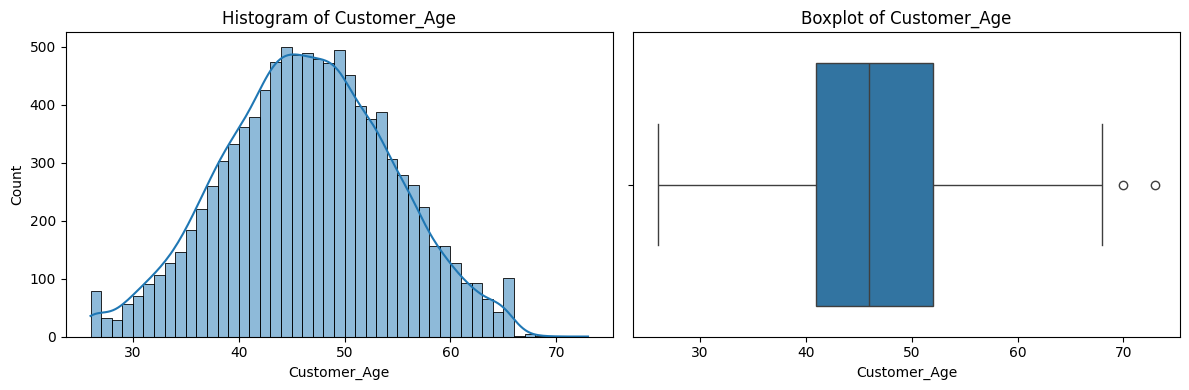

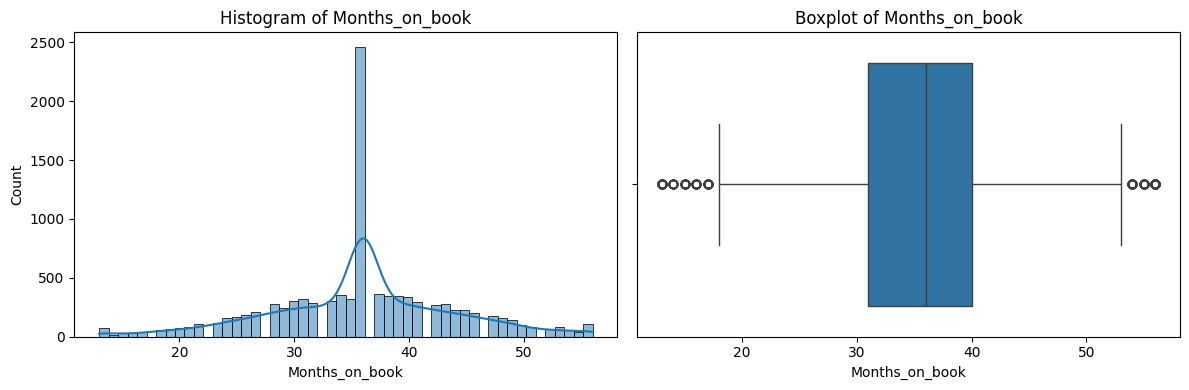

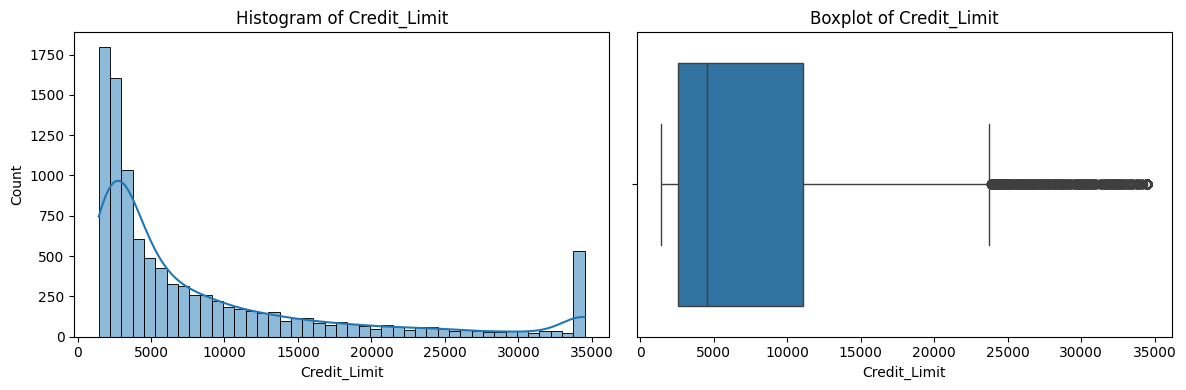

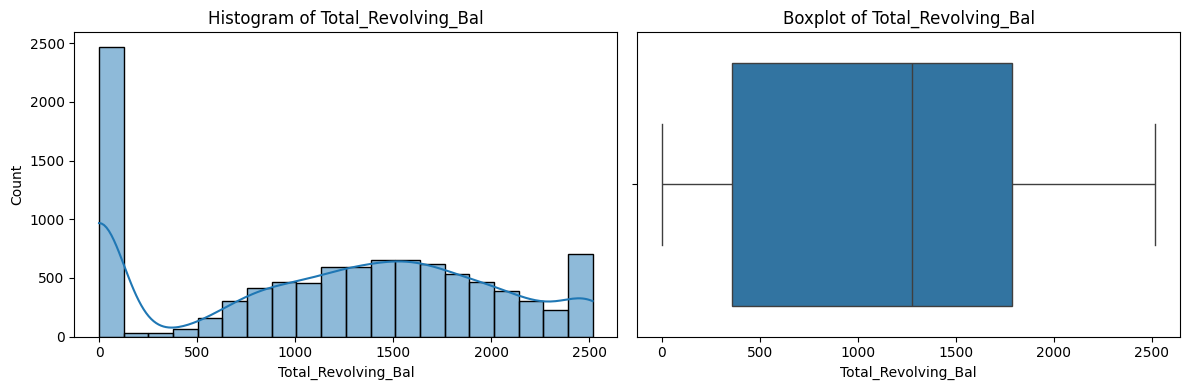

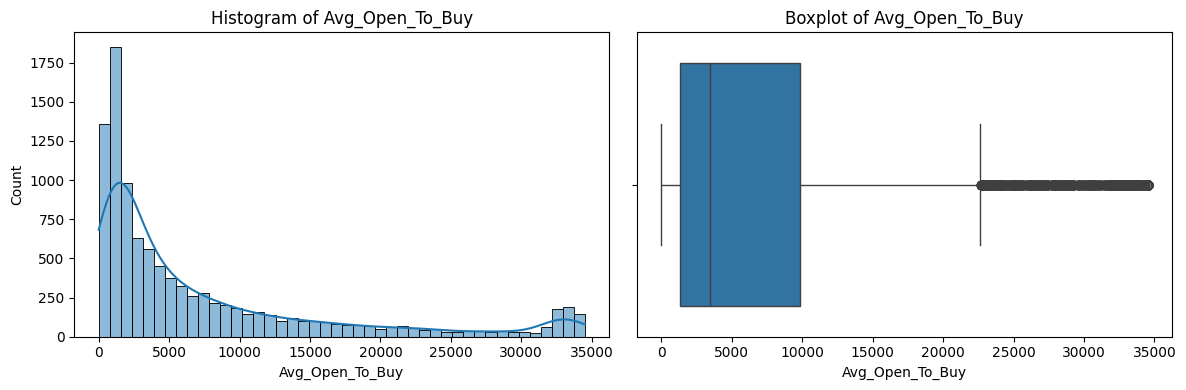

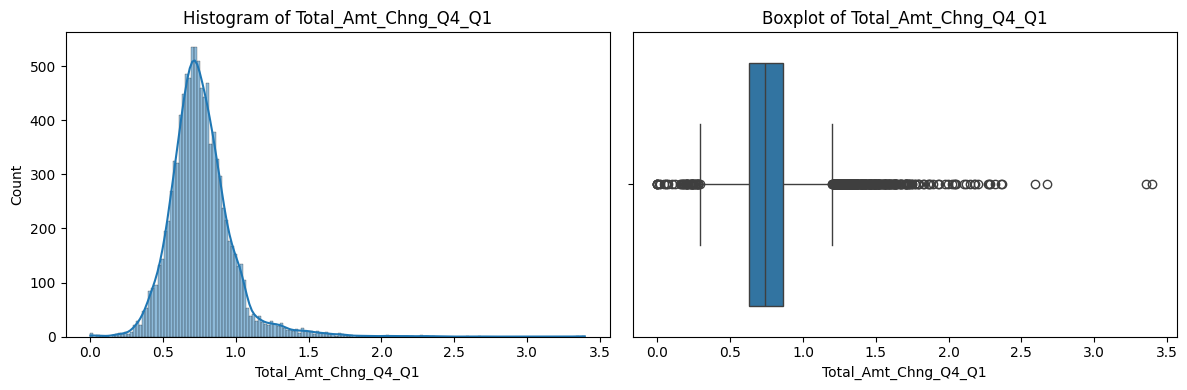

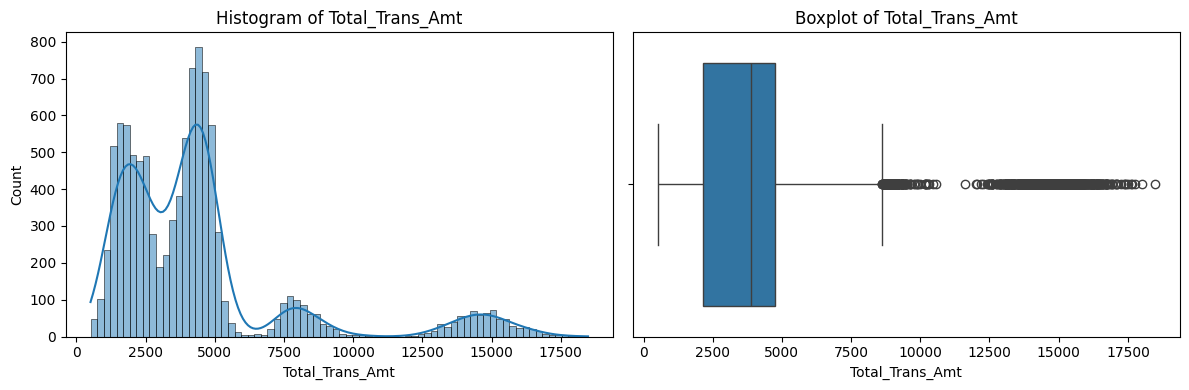

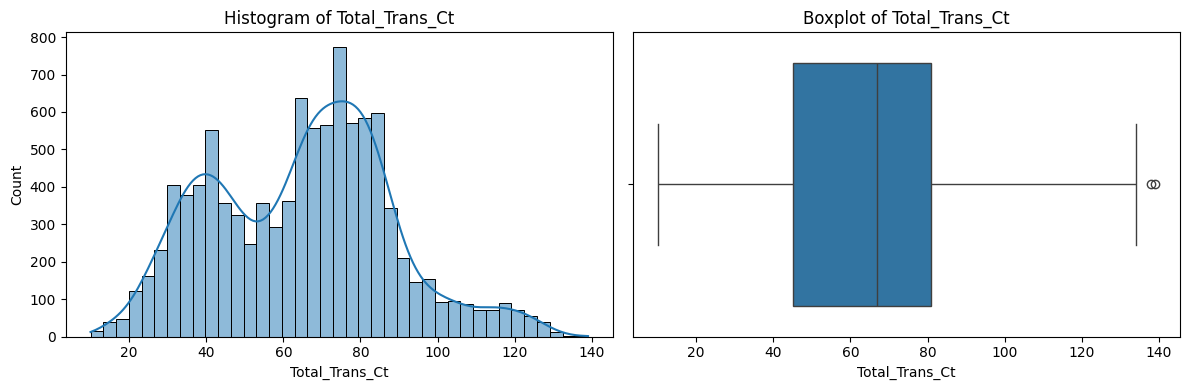

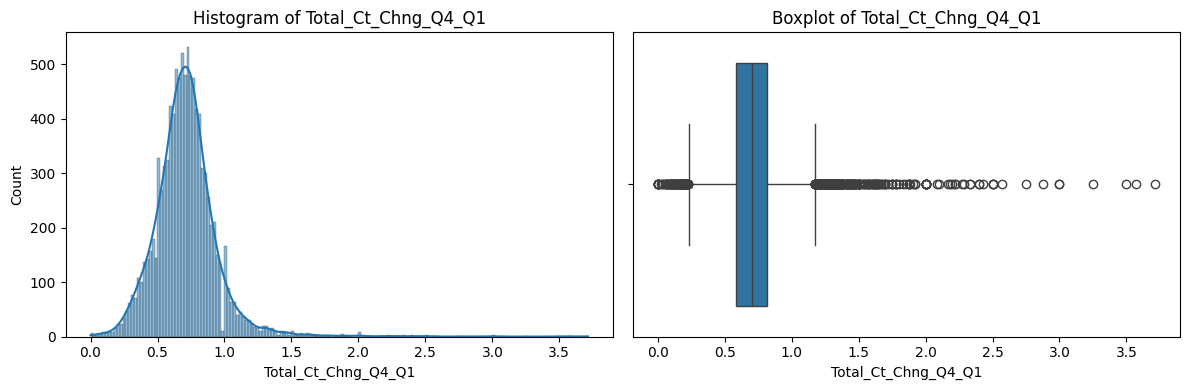

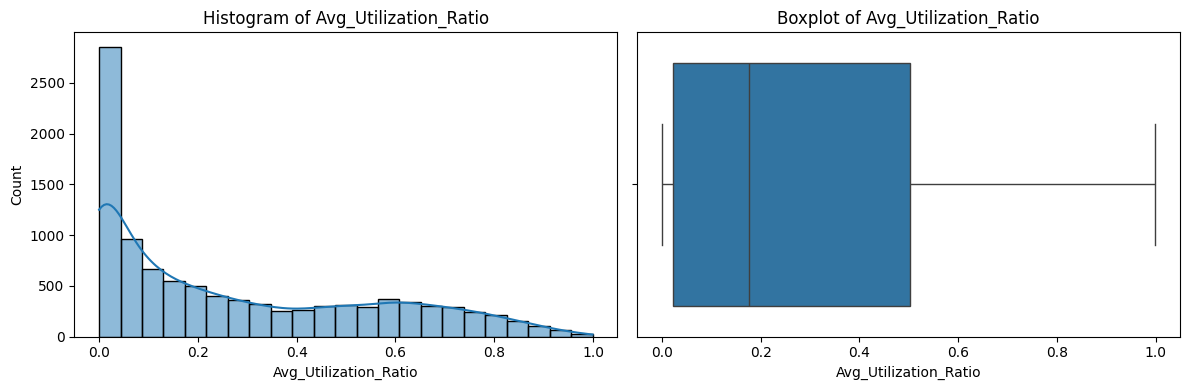

In [21]:
for col in continuous_cols:
    
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

* 나이: 정규분포 형태. 대부분 40~55세 구간에 집중되어 있다.

* 카드 가입 기간: 36개월에서 count 매우 높다.
이는 실제 카드 데이터에서 흔히 나타나는 3년 단위의 갱신 구조에 의한 것으로 알려져 있다. 이를 제외한 전반적인 분포는 고르게 퍼져있다.

* 신용 한도: 대부분 2,000~10,000 구간에 집중되어 있다. 35,000 근처에서 peak가 나타나는데, 이는 카드 등급별 한도 상한에 의한 것? 

* 리볼빙(이월 잔액): 0원(이월 없는 고객)이 제일 많다. 그 외 구간에서는 대체로 고른 분포를 보이다가, 가장 높은 금액에서 조금 높게 나타난다.

* Avg_Open_To_Buy = 신용한도-리볼빙 잔액 으로 만든 파생변수. 고객이 추가로 사용할 수 있는 신용 한도를 의미한다.

* Q4/Q1 거래금액: 대부분 0.6~0.9에 분포. Q1 시점에 비해 Q4 시점에 카드 사용 줄어든 고객이 많다. 

* 총 거래금액: 여러 peak가 나타난다. 소비 규모에 따른 여러 유형의 고객군이 존재하는 것으로 보인다.

* 총 거래횟수: peak 2개 나타난다. 카드 사용 빈도에 따라 서로 다른 고객군이 존재하는 것으로 보인다.

* Q4/Q1 거래횟수: 거래금액과 비슷한 패턴. 대부분 Q4에 거래 횟수 줄어들었다.

* utilization_ratio: 리볼빙/신용한도. 대부분 0 근처. 즉 카드 한도를 크게 사용하지 않는 고객이 많다.

이탈률 확인

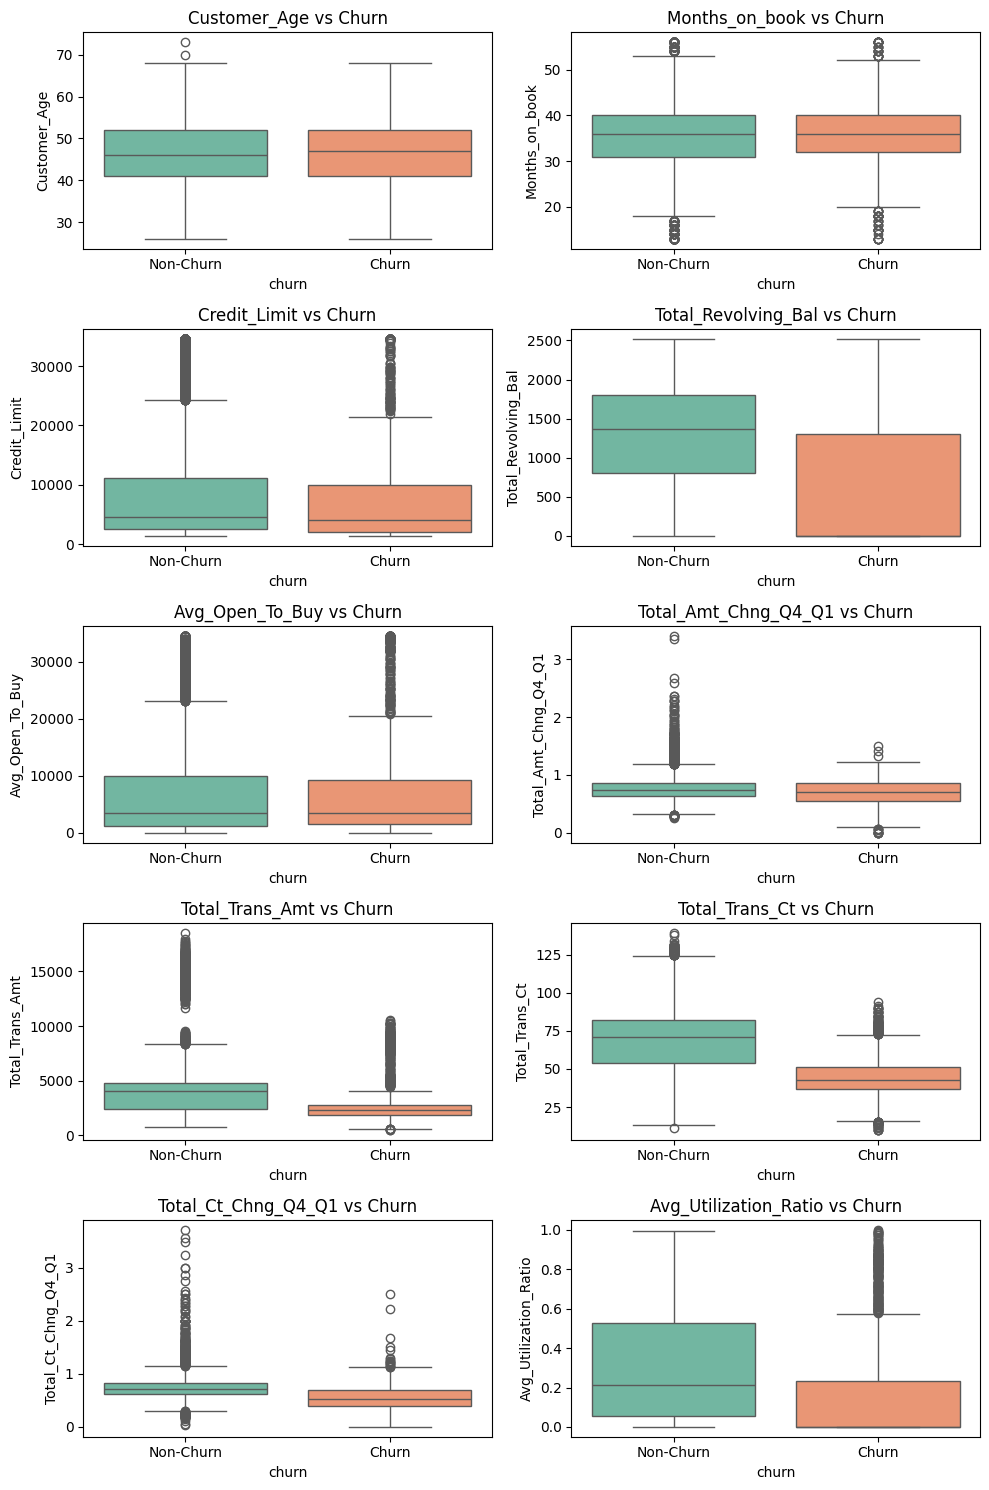

In [54]:
n_cols = 2
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(x='churn', y=col, hue='churn', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn')

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

설명력 높은 변수
* Total_Revolving_Bal
* Total_Amt_Chng_Q4_Q1
* Total_Ct_Chng_Q4_Q1

* Total_Trans_Amt
* Total_Trans_Ct
* Avg_Utilization_Ratio

#### Multivariate Analysis

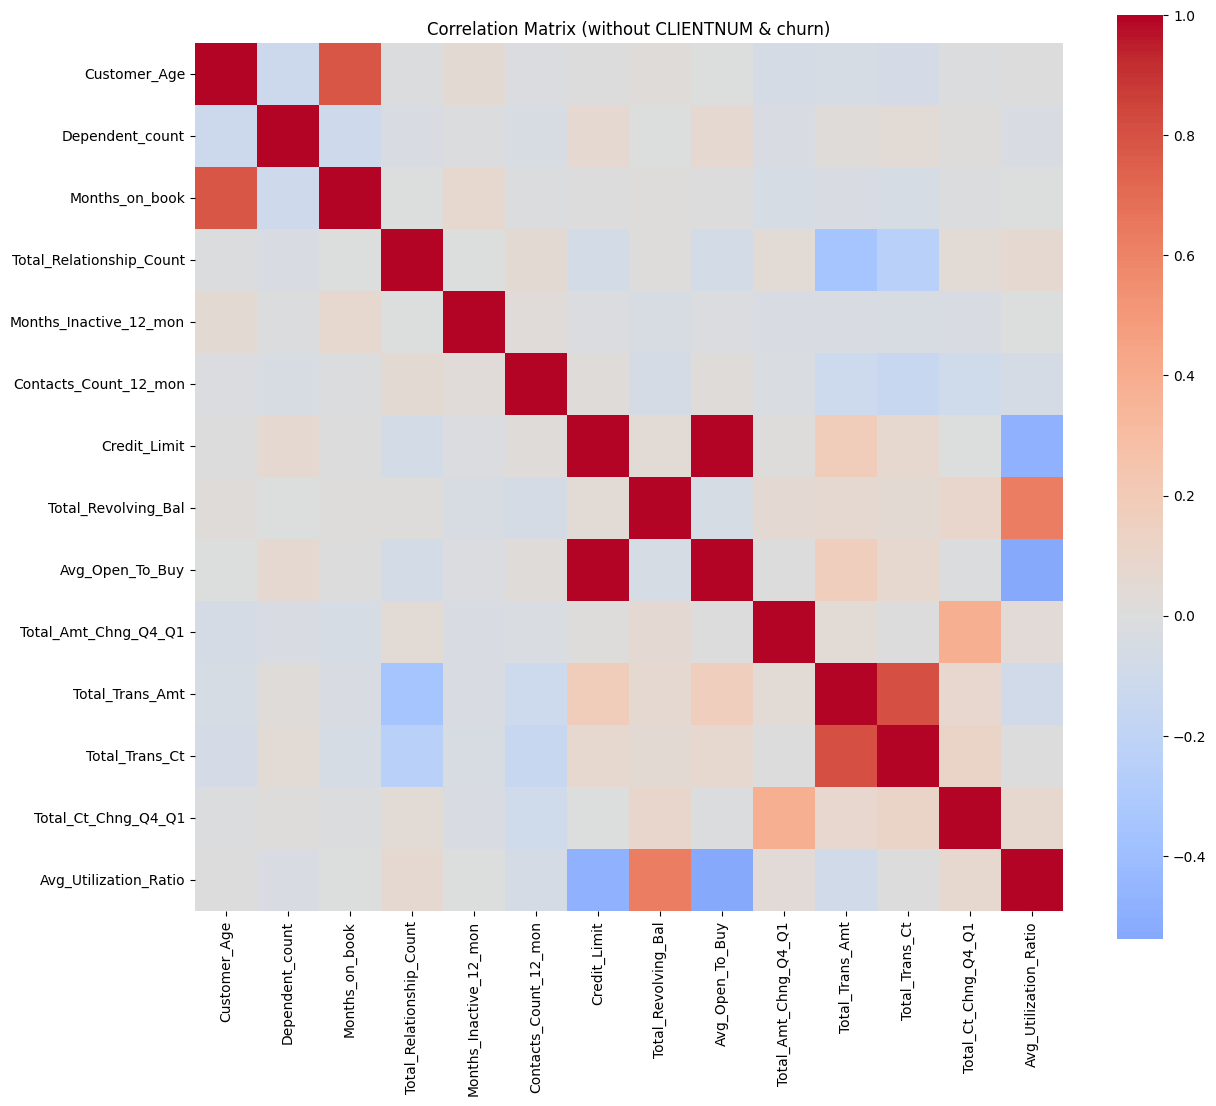

In [22]:
corr_df = df.drop(columns=['CLIENTNUM', 'churn'])

# 수치형만 (혹시 모르니 안전하게)
corr_df = corr_df.select_dtypes(include=np.number)

corr = corr_df.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            square=True)

plt.title("Correlation Matrix (without CLIENTNUM & churn)")
plt.show()

* 상관관계 높게 나타난 3개 pair는 파생된 변수이거나, 비슷한 변수.
(Credit_Limit ↔ Avg_Open_To_Buy, Total_Trans_Amt ↔ Total_Trans_Ct, Total_Amt_Chng_Q4_Q1 ↔ Total_Ct_Chng_Q4_Q1)

* 음의 상관관계 나타난 pair는 변수의 수학적 관계에 의해 나타나는 당연한 관계이다.
(Credit_Limit ↔ Avg_Utilization_Ratio, Avg_Open_To_Buy ↔ Avg_Utilization_Ratio)

* 추후 모델링 시 위의 변수들은 필요에 따라 선택하거나 일부 제거해야 한다.

추가: Total_Trans_Ct vs Total_Trans_Amt로 churn cluster 확인

<Axes: xlabel='Total_Trans_Ct', ylabel='Total_Trans_Amt'>

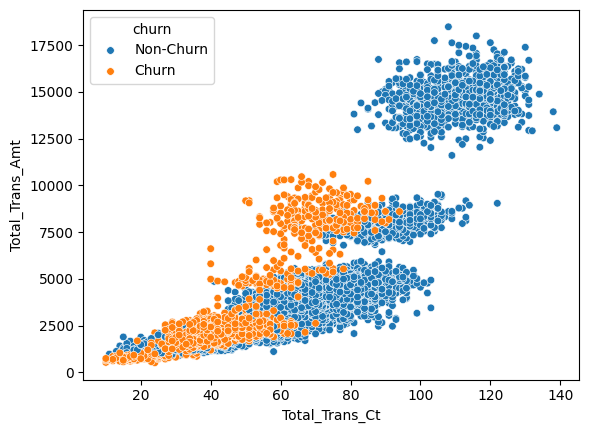

In [63]:
sns.scatterplot(
    data=df,
    x='Total_Trans_Ct',
    y='Total_Trans_Amt',
    hue='churn',
    s=30
)